# 17_机器学习模型评估方法-精确率

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 乳腺癌数据中 0 表示恶性；精确率使用 pos_label=0，报告键显式使用类别名称。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本篇文章，咱们来聊聊**精确率**这个内容\~

我们从生活中的一个例子来理解。

假设一个安检人员，任务是查找行李中有没有**违禁品**。你查了很多个包，然后标记了其中一些是「可能有违禁品」的。后来你发现：你确实查出来了一些违禁品，但有一些你以为是违禁品的其实不是。

这时候你会问自己：**我查出来的这些“可能是违禁品”的包里，到底有多少是真正的违禁品？**

这就是精确率要回答的问题：

> **精确率 = 真正是违禁品的包 / 所有你以为是违禁品的包**

在机器学习中，我们经常让模型去判断一个东西是不是某个类别，比如判断邮件是不是垃圾邮件。

我们把模型的判断分成4种情况：

| 实际是垃圾邮件 | 实际不是垃圾邮件 |
|-|-|
| **你说是** ✔️（判断正确）叫：真正（True Positive, TP） | ❌（判断错）叫：假正（False Positive, FP） |
| **你说不是** ❌（判断错）叫：假负（False Negative, FN） | ✔️（判断正确）叫：真负（True Negative, TN） |

精确率（Precision）就是只看你说是垃圾邮件的那些，看看有多少真的是垃圾邮件：

> **精确率（Precision） = TP / (TP + FP)**

也就是你**预测为正的样本中，有多少是真正的正例**。

那么，为什么精确率重要？

如果你做的是**肿瘤检测**，每判断一个人为「有肿瘤」，他可能就要接受进一步检查。

如果你判断错了（FP），就是把一个健康人当成了生病的人。

精确率高，说明你说是「生病的人」，大多数真的患病了，**减少了误报**，避免过度检查。

## 核心原理

我们定义：

- $TP$：真正例（True Positive） - 预测为正，实际也为正。
- $FP$：假正例（False Positive） - 预测为正，实际为负。
- $FN$：假负例（False Negative） - 预测为负，实际为正。
- $TN$：真负例（True Negative） - 预测为负，实际也为负。

> 精确率（Precision）就是所有预测为正的样本中，有多少是真正的正例。

公式：


$$
\text{Precision} = \frac{TP}{TP + FP}
$$


让我们来一步一步拆解这个公式：

#### 步骤1：关注“模型预测为正”的样本

模型预测为正的样本有哪些？

- **真正例**：模型说它是正的，它确实是正的 → TP
- **假正例**：模型说它是正的，但它实际上是负的 → FP

所以，模型预测为正的样本总数是：


$$
\text{预测为正的样本数} = TP + FP
$$


#### 步骤2：其中哪些是真的？

在这些预测为正的样本中，真正的是正的就是 TP。

所以精确率 = 真正的是正的 / 预测为正的总数：


$$
\text{Precision} = \frac{TP}{TP + FP}
$$


但要注意：

- 精确率**不考虑**那些模型预测为负的样本（也就是说，跟 TN、FN 没有关系）。
- 精确率关注的是：**你说对的“正例”有多少是真的？**
- 精确率高 ≠ 模型就一定好，需要结合召回率看，下面是常见搭配：

## 精确率相关的常见组合

| 评估指标 | 公式 | 含义 |
|-|-|-|
| 精确率（Precision） | $\frac{TP}{TP + FP}$ | 你说是的有多少真的是 |
| 召回率（Recall） | $\frac{TP}{TP + FN}$ | 实际是的，你找出了多少 |
| F1 分数 | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | 精确率和召回率的平衡 |

## 计算流程

**给定：**

你有模型的预测结果，以及真实标签。

**步骤：**

1. **收集预测数据**：对每个样本，记下预测结果和真实结果。
2. **计算 TP**：统计哪些样本是「预测为正」且「实际为正」。
3. **计算 FP**：统计哪些样本是「预测为正」但「实际为负」。
4. **套入公式**：


$$
\text{Precision} = \frac{TP}{TP + FP}
$$


1. **输出精确率**：这是模型对正类预测的“可信度”。

## 举个简单例子

你让模型判断哪些邮件是垃圾邮件（正类），共判断了10封邮件如下：

| 邮件编号 | 实际是否垃圾 | 预测是否垃圾 |
|-|-|-|
| 1 | 是 | 是 |
| 2 | 是 | 是 |
| 3 | 否 | 是 |
| 4 | 否 | 是 |
| 5 | 是 | 否 |
| 6 | 否 | 否 |
| 7 | 否 | 否 |
| 8 | 是 | 是 |
| 9 | 否 | 否 |
| 10 | 是 | 是 |

统计：

- TP = 4（邮件1、2、8、10）
- FP = 2（邮件3、4）


$$
\text{Precision} = \frac{4}{4 + 2} = \frac{4}{6} = 0.6667
$$


说明：你说是垃圾邮件的那些邮件中，大概有 **66.67%** 真的是垃圾邮件。

## 完整案例

乳腺癌是女性中常见的癌症之一，早期检测对于提高生存率非常重要。我们希望通过机器学习模型，对是否患有乳腺癌进行预测。由于误诊一个健康人（假正例）会导致不必要的心理和经济负担，所以我们特别关注**精确率（Precision）**。

目标：构建一个乳腺癌分类器，并重点评估模型的**精确率**。

我们使用 `sklearn` 中的经典乳腺癌数据集：`load_breast_cancer()`。

- 特征数：30个
- 类别：恶性(Malignant)，良性(Benign)

### 完整代码

精确率（Precision）: 0.9512

分类报告:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



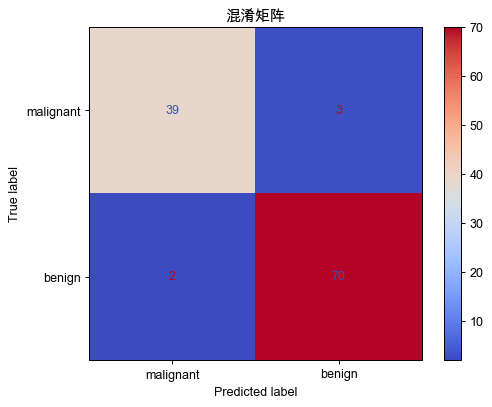

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11323/926477758.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='Set2')


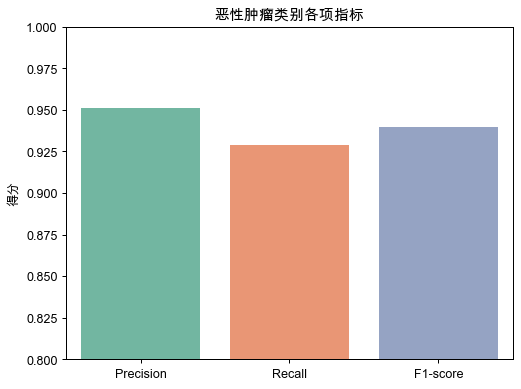

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


# 1. 加载数据集
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# 2. 数据划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 标准化处理
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 构建模型
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. 预测
y_pred = model.predict(X_test_scaled)

# 6. 评估精确率
precision = precision_score(y_test, y_pred, pos_label=0)
print(f"精确率（Precision）: {precision:.4f}")

# 7. 显示分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 8. 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='coolwarm')
plt.title("混淆矩阵")
plt.show()

# 9. 精确率与其他指标条形图
report_dict = classification_report(y_test, y_pred, target_names=data.target_names, output_dict=True)
precision_malignant = report_dict["malignant"]["precision"]
recall_malignant = report_dict["malignant"]["recall"]
f1_malignant = report_dict["malignant"]["f1-score"]

# 可视化
metrics = ['Precision', 'Recall', 'F1-score']
values = [precision_malignant, recall_malignant, f1_malignant]

sns.barplot(x=metrics, y=values, palette='Set2')
plt.title("恶性肿瘤类别各项指标")
plt.ylim(0.8, 1.0)
plt.ylabel("得分")
plt.show()

#### 步骤1：加载数据

我们使用的是 `load_breast_cancer` 数据集，这是一个标准医学数据集，有569条记录，每条记录30个特征。

- **target = 0** 表示恶性（Malignant）
- **target = 1** 表示良性（Benign）

#### 步骤2：数据划分

使用 `train_test_split` 按 8:2 的比例划分训练集和测试集，并使用 `stratify=y` 确保类别比例一致。

#### 步骤3：标准化处理

由于各特征量纲不同，我们用 `StandardScaler` 对数据进行标准化，使其均值为0，方差为1。

#### 步骤4：构建模型

使用 `RandomForestClassifier`，这是一个强大的集成模型，适用于非线性分类任务。它不会对数据有太多假设，适合医学数据建模。

#### 步骤5：模型预测

我们对测试数据进行预测，得到预测值 `y_pred`。

#### 步骤6：精确率计算

使用 `precision_score(y_test, y_pred)` 来计算精确率，衡量模型对“正类”判断的准确性。

#### 步骤7：分类报告

使用 `classification_report` 生成详细的 Precision、Recall、F1 分数，可以分别看到在“恶性”和“良性”上的表现。

#### 步骤8：混淆矩阵可视化

通过 `ConfusionMatrixDisplay` 展示混淆矩阵，颜色使用 `coolwarm`，红蓝对比鲜明，便于观察模型在各类别的误判情况。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

#### 步骤9：恶性类别的各项指标可视化

展示恶性肿瘤的 Precision、Recall 和 F1-score，不同颜色使不同指标之间的差异一目了然。

### 使用精确率的优缺点分析

**优点**：

1. **控制误报**：当错误地将负类（如健康人）预测为正类（如癌症患者）代价很高时，精确率就是关键指标。
2. **对不平衡数据友好**：在类别不平衡的情况下，比准确率更有效。
3. **直观反映预测可信度**：预测为正的结果有多少是对的，一目了然。

**缺点**：

1. **不考虑漏报（FN）**：精确率不看你漏掉了多少真正的正例，容易忽略**召回率**。
2. **无法独立衡量模型质量**：一个模型精确率很高，但如果召回率极低，仍然是不合格的模型。
3. **容易被“策略性预测”干扰**：模型可以只预测最有把握的正类，从而虚高精确率。

### 精确率适合的使用场景

**精确率是优选的场景：**

- **医疗预筛查**：比如癌症初步筛查中，不希望误将健康人判断为“疑似阳性”而让人恐慌。
- **垃圾邮件过滤**：如果误把正常邮件当垃圾邮件删了，后果可能比漏掉一些垃圾邮件更严重。
- **金融欺诈检测**：一笔正常交易被误判为欺诈，会导致用户账户冻结、投诉，精确率必须高。

**精确率不适用的场景：**

- **安全/安防监控（如机场毒品检查）**：此类任务宁愿误报（FP），也不能漏报（FN），需要**召回率优先**。
- **疫情追踪模型**：目标是找到尽可能多的感染者，即使会误抓一些未感染者，此时精确率不是第一考虑。

通过这个实际案例，我们深入理解了：

1. **精确率是什么？**

   - 是对模型“预测为正”的结果中，正确的比例。
2. **如何计算？**$\text{Precision} = \frac{TP}{TP + FP}$
3. **何时使用精确率？**

   - 当**误报的代价很高**时，优先使用精确率。
4. **如何在实际中使用？**

   - 结合混淆矩阵、分类报告、可视化，一步步监控模型性能。

本案例结合实际医学背景，展示了如何利用精确率评估机器学习模型的可靠性，以及如何可视化地解读它在任务中的表现。